# Multi-stage ABC using saved `gp_module.joblib`

This notebook implements a **multi-stage / delayed-acceptance ABC** workflow using the GP module you trained and saved as

```text
saved_models/gp_module.joblib
```

Pipeline:

\[
	heta_{pop}=(k_{12}^{CTMC},k_{21}^{CTMC})
	o 	ext{cheap population CTMC screen}
	o 	ext{saved GP module}
	o 	heta_{spatial}=(k_{12}^{site},k_{21}^{base})
	o 	ext{short spatial screen}
	o 	ext{full spatial ABC check}.
\]

The final accept/reject decision uses the **spatial simulator distance**.  The CTMC screen is only used to avoid wasting spatial simulations on clearly bad proposals.


## 1. Load modules

In [1]:
from pathlib import Path
import importlib.util
import sys
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import logsumexp
import joblib

try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False


def load_module(module_name, filename_candidates):
    search_roots = [
        Path.cwd(),
        Path.cwd() / "python_version",
        Path.cwd().parent,
        Path.cwd().parent / "python_version",
        Path("/mnt/data"),
    ]
    for root in search_roots:
        for name in filename_candidates:
            path = root / name
            if path.exists():
                spec = importlib.util.spec_from_file_location(module_name, path)
                mod = importlib.util.module_from_spec(spec)
                sys.modules[module_name] = mod
                spec.loader.exec_module(mod)
                print(f"Loaded {module_name} from {path}")
                return mod
    raise FileNotFoundError(f"Could not find {module_name} in {search_roots}")


# Load in dependency order. Parenthesized names are included for uploaded files.
gillespie = load_module("gillespie", ["gillespie.py", "gillespie(20).py"])
prc1 = load_module("prc1", ["prc1.py", "prc1(19).py"])
prc1_state = load_module("prc1_state", ["prc1_state.py", "prc1_state(18).py"])
run_gillespie = load_module("run_gillespie", ["run_gillespie.py", "run_gillespie(18).py"])

from prc1_state import State

Loaded gillespie from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\gillespie.py
Loaded prc1 from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1.py
Loaded prc1_state from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\prc1_state.py
Loaded run_gillespie from C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\run_gillespie.py


## 1b. Load saved GP module

This notebook does **not** retrain the GP. It loads `saved_models/gp_module.joblib`.

In [2]:
def find_gp_module():
    candidates = [
        Path.cwd() / "saved_models" / "gp_module.joblib",
        Path.cwd() / "gp_module.joblib",
        Path("/mnt/data") / "saved_models" / "gp_module.joblib",
        Path("/mnt/data") / "gp_module.joblib",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "Could not find gp_module.joblib. Run train_gp_module_300.ipynb first, "
        "or put the saved module at saved_models/gp_module.joblib."
    )

GP_MODULE_PATH = find_gp_module()
gp_module = joblib.load(GP_MODULE_PATH)
inverse_gp = gp_module["model"]

print("Loaded GP module from:", GP_MODULE_PATH)
print("model_name:", gp_module.get("model_name"))
print("model_type:", gp_module.get("model_type"))
print("input_names:", gp_module.get("input_names"))
print("output_names:", gp_module.get("output_names"))
print("trained_on_n_targets:", gp_module.get("trained_on_n_targets"))
print("gp_metrics:", gp_module.get("gp_metrics"))


def predict_spatial_from_population_gp(k12_ctmc, k21_ctmc, return_std=False):
    """Use the saved GP module to predict spatial parameters from CTMC parameters."""
    X_new = np.array([[np.log(float(k12_ctmc)), np.log(float(k21_ctmc))]], dtype=float)

    if return_std and hasattr(inverse_gp, "estimators_"):
        means = []
        stds = []
        for est in inverse_gp.estimators_:
            m, s = est.predict(X_new, return_std=True)
            means.append(float(m[0]))
            stds.append(float(s[0]))
        y_log = np.array(means, dtype=float)
        y_log_std = np.array(stds, dtype=float)
    else:
        y_log = inverse_gp.predict(X_new)[0]
        y_log_std = np.array([np.nan, np.nan], dtype=float)

    k12_site = float(np.exp(y_log[0]))
    k21_base = float(np.exp(y_log[1]))

    # Keep predictions inside the module training/search bounds when available.
    k12_site_bounds = gp_module.get("k12_site_bounds", [K12_SITE_MIN, K12_SITE_MAX]) if "K12_SITE_MIN" in globals() else gp_module.get("k12_site_bounds", None)
    k21_base_bounds = gp_module.get("k21_base_bounds", [K21_BASE_MIN, K21_BASE_MAX]) if "K21_BASE_MIN" in globals() else gp_module.get("k21_base_bounds", None)
    if k12_site_bounds is not None:
        k12_site = float(np.clip(k12_site, float(k12_site_bounds[0]), float(k12_site_bounds[1])))
    if k21_base_bounds is not None:
        k21_base = float(np.clip(k21_base, float(k21_base_bounds[0]), float(k21_base_bounds[1])))

    if return_std:
        return k12_site, k21_base, float(y_log_std[0]), float(y_log_std[1])
    return k12_site, k21_base

print("Example GP prediction for population k12=10, k21=0.2:")
print(predict_spatial_from_population_gp(10.0, 0.2, return_std=True))

Loaded GP module from: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\saved_models\gp_module.joblib
model_name: gp_module
model_type: MultiOutputRegressor(GaussianProcessRegressor)
input_names: ['k12_ctmc', 'k21_ctmc']
output_names: ['k12_site', 'k21_base']
trained_on_n_targets: 300
gp_metrics: {'r2': [0.9935764744803169, 0.9938144535247605], 'mae': [0.049159379283094724, 0.08769869540995594], 'mean_mae': 0.06842903734652533}
Example GP prediction for population k12=10, k21=0.2:
(3.457431368172938, 0.1152552937818118, 0.09116509551338614, 0.09146292752029844)


## 2. Fixed model settings

In [3]:
# Fixed spatial parameters. Pull these from the GP module when possible so ABC matches training.
INIT_BIND = float(gp_module.get("init_bind", 0.000238))   # first-head attachment rate per available site
K_DET_1   = float(gp_module.get("k_det_1", 0.1))         # singly bound detachment rate

# Observation grid
DT_OBS = 4.0
T_END = 68.0
times_obs = np.arange(0.0, T_END + DT_OBS, DT_OBS)

# Geometry/constants matching run_gillespie.py defaults
MICROTUBULE_LENGTH = 5000
SITE_SPACING = 8
MICROTUBULE_OFFSET = 0
SPRING_CONSTANT = 2
REST_LENGTH = 32
KBT = 4.1
MICROTUBULE_SEPARATION = 30
BASE_HOPPING_RATE = 1
NUM_SITES = int(MICROTUBULE_LENGTH / SITE_SPACING) + 1

# Spatial options. Use the same options saved with the GP module.
SPATIAL_KWARGS = dict(gp_module.get("spatial_kwargs", dict(
    cooperativity_energy=0.0,
    enable_initial_attach_cooperativity=False,
    enable_second_head_attach_cooperativity=False,
    enable_second_head_detach_cooperativity=False,
    enable_hopping=False,
    max_steps=200_000,
)))

# Cheap population CTMC fixed values
R01_CTMC_FIXED = 2.0 * INIT_BIND * NUM_SITES
K10_CTMC_FIXED = K_DET_1

print("times_obs:", times_obs)
print("INIT_BIND:", INIT_BIND)
print("K_DET_1:", K_DET_1)
print("NUM_SITES:", NUM_SITES)
print("R01_CTMC_FIXED:", R01_CTMC_FIXED)
print("K10_CTMC_FIXED:", K10_CTMC_FIXED)
print("SPATIAL_KWARGS:", SPATIAL_KWARGS)

times_obs: [ 0.  4.  8. 12. 16. 20. 24. 28. 32. 36. 40. 44. 48. 52. 56. 60. 64. 68.]
INIT_BIND: 0.000238
K_DET_1: 0.1
NUM_SITES: 626
R01_CTMC_FIXED: 0.297976
K10_CTMC_FIXED: 0.1
SPATIAL_KWARGS: {'cooperativity_energy': 0.0, 'enable_initial_attach_cooperativity': False, 'enable_second_head_attach_cooperativity': False, 'enable_second_head_detach_cooperativity': False, 'enable_hopping': False, 'max_steps': 200000}


## 3. Multi-level ABC settings

In [4]:
# Prior range for population parameters inferred by ABC.
# Use the GP module bounds, because the GP is only reliable inside its training region.
K12_CTMC_MIN, K12_CTMC_MAX = map(float, gp_module.get("k12_ctmc_bounds", [1.0, 30.0]))
K21_CTMC_MIN, K21_CTMC_MAX = map(float, gp_module.get("k21_ctmc_bounds", [0.02, 1.0]))

# Valid range for GP-predicted spatial parameters.
K12_SITE_MIN, K12_SITE_MAX = map(float, gp_module.get("k12_site_bounds", [0.1, 20.0]))
K21_BASE_MIN, K21_BASE_MAX = map(float, gp_module.get("k21_base_bounds", [0.005, 1.0]))

# Summary statistic. Use ["N"] because total occupancy is the observable.
SUMMARY_KEYS = ["N"]
USE_VARIANCE_IN_SUMMARY = True

# Synthetic observation settings.
# For real data, replace the observed data block below.
OBS_MODE = "synthetic_spatial"
TRUE_K12_SITE = 5.88
TRUE_K21_BASE = 0.1
N_OBS_REPS = 10
OBS_SEED = 2026

# Cheap and expensive replicate counts.
N_POP_REPS = 30              # cheap CTMC reps for screening
N_SPATIAL_REPS_SHORT = 2     # rough spatial reps for short screen
N_SPATIAL_REPS_FULL = 8      # final spatial reps for expensive check

# Pilot calibration. Increase after the notebook is stable.
N_PILOT = 80
PILOT_POP_QUANTILE = 80.0
PILOT_SHORT_QUANTILE = 70.0
PILOT_SPATIAL_QUANTILE = 60.0
PILOT_MAX_SPATIAL = 40

# SMC settings. Start small; increase for a serious run.
P_PARTICLES = 30
G_GENERATIONS = 3
BATCH_FACTOR = 4
COV_SCALE = 2.0
EPS_SPATIAL_UPDATE_QUANTILE = 50.0
MAX_PROPOSALS_PER_GENERATION = 5000

# Parallel settings. Use loky for safer RNG/process isolation.
N_JOBS = -1
PARALLEL_BACKEND = "loky"  # change to "threads" if loky has pickling issues

RANDOM_SEED = 123
rng_global = np.random.default_rng(RANDOM_SEED)

print("CTMC bounds:", (K12_CTMC_MIN, K12_CTMC_MAX), (K21_CTMC_MIN, K21_CTMC_MAX))
print("spatial bounds:", (K12_SITE_MIN, K12_SITE_MAX), (K21_BASE_MIN, K21_BASE_MAX))

CTMC bounds: (1.0, 30.0) (0.02, 1.0)
spatial bounds: (0.1, 20.0) (0.005, 1.0)


## 4. Utility functions

In [5]:
def log_uniform(rng, low, high, size=None):
    return np.exp(rng.uniform(np.log(low), np.log(high), size=size))


def safe_log_ratio(a, b, eps=1e-12):
    return np.log((float(a) + eps) / (float(b) + eps))


def stack_runs(runs, key):
    return np.asarray([np.asarray(run[key], dtype=float) for run in runs], dtype=float)


def mean_traj(runs, key):
    return stack_runs(runs, key).mean(axis=0)


def summarize_runs(runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY):
    """Summary = concatenated means and optionally variances for selected keys."""
    pieces = []
    for key in keys:
        X = stack_runs(runs, key)
        pieces.append(X.mean(axis=0))
        if use_variance:
            if X.shape[0] > 1:
                pieces.append(X.var(axis=0, ddof=1))
            else:
                pieces.append(np.zeros(X.shape[1], dtype=float))
    return np.concatenate(pieces).astype(float)


def make_distance_function(summary_obs):
    # Prevent a few large coordinates from dominating; keep distance dimensionless.
    scale = np.maximum(np.abs(summary_obs), 1.0)
    def distance(summary_sim):
        d = (np.asarray(summary_sim, dtype=float) - summary_obs) / scale
        return float(np.sqrt(np.mean(d * d)))
    return distance


def _parallel_map(fn, items, n_jobs=N_JOBS, backend=PARALLEL_BACKEND):
    if JOBLIB_AVAILABLE and int(n_jobs) != 1:
        if backend == "loky":
            return Parallel(n_jobs=int(n_jobs), backend="loky")(delayed(fn)(x) for x in items)
        return Parallel(n_jobs=int(n_jobs), prefer="threads")(delayed(fn)(x) for x in items)
    return [fn(x) for x in items]


def format_seconds(seconds):
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.1f}s"
    minutes, sec = divmod(seconds, 60)
    if minutes < 60:
        return f"{int(minutes)}m {sec:.1f}s"
    hours, rem = divmod(minutes, 60)
    return f"{int(hours)}h {int(rem)}m {sec:.1f}s"

## 5. Cheap population CTMC simulator

In [6]:
def simulate_ctmc_one(R01, k10, k12, k21, times_obs, seed=None):
    """Simulate the reduced CTMC and return N,n1,n2 on times_obs."""
    rng = np.random.default_rng(seed)
    times_obs = np.asarray(times_obs, dtype=float)

    n1 = 0
    n2 = 0
    t = 0.0

    n1_out = np.zeros(len(times_obs), dtype=float)
    n2_out = np.zeros(len(times_obs), dtype=float)
    N_out = np.zeros(len(times_obs), dtype=float)

    obs_idx = 0
    while obs_idx < len(times_obs) and times_obs[obs_idx] <= 0:
        n1_out[obs_idx] = n1
        n2_out[obs_idx] = n2
        N_out[obs_idx] = n1 + n2
        obs_idx += 1

    while obs_idx < len(times_obs):
        rates = np.array([R01, k10 * n1, k12 * n1, k21 * n2], dtype=float)
        a0 = rates.sum()

        if a0 <= 0 or not np.isfinite(a0):
            while obs_idx < len(times_obs):
                n1_out[obs_idx] = n1
                n2_out[obs_idx] = n2
                N_out[obs_idx] = n1 + n2
                obs_idx += 1
            break

        dt = rng.exponential(1.0 / a0)
        t_next = t + dt

        while obs_idx < len(times_obs) and times_obs[obs_idx] < t_next:
            n1_out[obs_idx] = n1
            n2_out[obs_idx] = n2
            N_out[obs_idx] = n1 + n2
            obs_idx += 1

        if obs_idx >= len(times_obs):
            break

        t = t_next
        u = rng.random() * a0
        if u < rates[0]:
            n1 += 1
        elif u < rates[0] + rates[1]:
            if n1 > 0:
                n1 -= 1
        elif u < rates[0] + rates[1] + rates[2]:
            if n1 > 0:
                n1 -= 1
                n2 += 1
        else:
            if n2 > 0:
                n2 -= 1
                n1 += 1

    return {"times": times_obs, "n1": n1_out, "n2": n2_out, "N": N_out}


def simulate_ctmc_many(R01, k10, k12, k21, times_obs, n_reps=50, seed=1):
    rng = np.random.default_rng(seed)
    runs = []
    for _ in range(int(n_reps)):
        runs.append(
            simulate_ctmc_one(
                R01, k10, k12, k21, times_obs,
                seed=int(rng.integers(0, 2**31 - 1)),
            )
        )
    return runs

## 6. Spatial simulator with report-map diagnostics

In [7]:
def state_diagnostics_for_report_map(state):
    """
    Diagnostics for your original report map:
      - N, n1, n2
      - A_spatial = average available sites per microtubule
      - m_sum_capped = sum_i min(m_i,3), using reachable offsets {-1,0,1}
      - k21_sum_actual = sum_j p_j.detachment_rate over doubly bound PRC1s
    """
    doubly = list(state.doubly_attached_prc1)
    singly = list(state.top_attached_prc1) + list(state.bottom_attached_prc1)

    n2 = len(doubly)
    n1 = len(singly)

    A_top = len(state.top_untaken_sites)
    A_bottom = len(state.bottom_untaken_sites)
    A_spatial = 0.5 * (A_top + A_bottom)

    m_sum_capped = 0.0
    k12_actual_sum = 0.0

    for p in singly:
        k12_actual_sum += float(p.double_attachment_rate)
        closest = p.closest_index_on_other_side
        if closest is None:
            continue

        count = 0
        for offset in (-1, 0, 1):
            target = int(closest + offset)
            if target < 0 or target >= state.num_sites:
                continue

            if p.top_head_is_attached:
                if target in state.bottom_untaken_sites:
                    count += 1
            elif p.bottom_head_is_attached:
                if target in state.top_untaken_sites:
                    count += 1

        m_sum_capped += min(count, 3)

    k21_sum_actual = float(sum(float(p.detachment_rate) for p in doubly))

    return dict(
        N=float(n1 + n2),
        n1=float(n1),
        n2=float(n2),
        A_spatial=float(A_spatial),
        m_sum_capped=float(m_sum_capped),
        k12_actual_sum=float(k12_actual_sum),
        k21_sum_actual=float(k21_sum_actual),
    )


def run_spatial_diagnostic_one(k12_site, k21_base, times_obs, seed=None, spatial_kwargs=None):
    """Run one spatial trajectory and sample diagnostics on times_obs."""
    np.random.seed(None if seed is None else int(seed))
    spatial_kwargs = dict(SPATIAL_KWARGS if spatial_kwargs is None else spatial_kwargs)

    state = State(
        MICROTUBULE_LENGTH,
        SITE_SPACING,
        MICROTUBULE_OFFSET,
        SPRING_CONSTANT,
        REST_LENGTH,
        KBT,
        MICROTUBULE_SEPARATION,
        INIT_BIND,
        K_DET_1,
        float(k12_site),
        float(k21_base),
        BASE_HOPPING_RATE,
        spatial_kwargs.get("cooperativity_energy", 0.0),
        spatial_kwargs.get("enable_initial_attach_cooperativity", False),
        spatial_kwargs.get("enable_second_head_attach_cooperativity", False),
        spatial_kwargs.get("enable_second_head_detach_cooperativity", False),
    )

    enable_hopping = spatial_kwargs.get("enable_hopping", False)
    max_steps = int(spatial_kwargs.get("max_steps", 200_000))
    end_time = float(np.asarray(times_obs)[-1])

    def rate_function(state):
        initial_binding_rate = state.initial_binding_rate
        if len(state) == 0:
            return [initial_binding_rate, 0, 0, 0, 0] if enable_hopping else [initial_binding_rate, 0, 0]

        rates = [initial_binding_rate] + [0] * (len(state) - 1)
        for p in state:
            rates.append(p.double_attachment_rate)
        for p in state:
            rates.append(p.detachment_rate)

        if enable_hopping:
            for p in state:
                rates.append(p.total_bottom_hopping_rate)
            for p in state:
                rates.append(p.total_top_hopping_rate)

        return rates

    def single_attach_func(state, index):
        state.single_attach_prc1()

    def double_attach_func(state, index):
        state.double_attach_prc1(index)

    def detach_func(state, index):
        state.detach_prc1(index)

    def hop_bottom_func(state, index):
        state.hop_bottom(index)

    def hop_top_func(state, index):
        state.hop_top(index)

    if enable_hopping:
        reaction_functions = [single_attach_func, double_attach_func, detach_func, hop_bottom_func, hop_top_func]
    else:
        reaction_functions = [single_attach_func, double_attach_func, detach_func]

    event_times = [0.0]
    event_stats = [state_diagnostics_for_report_map(state)]

    t = 0.0
    steps = 0
    while t < end_time and steps < max_steps:
        t = gillespie.gillespie_step(state, t, rate_function, reaction_functions)
        event_times.append(float(t))
        event_stats.append(state_diagnostics_for_report_map(state))
        steps += 1

        if not np.isfinite(t):
            raise RuntimeError("Non-finite time in spatial simulation")

    if steps >= max_steps:
        raise RuntimeError("Spatial simulation hit max_steps")

    event_times = np.asarray(event_times, dtype=float)
    times_obs = np.asarray(times_obs, dtype=float)

    out = {"times": times_obs.copy()}
    for key in event_stats[0].keys():
        arr = np.zeros(len(times_obs), dtype=float)
        for i, tt in enumerate(times_obs):
            idx = np.searchsorted(event_times, tt, side="right") - 1
            idx = max(idx, 0)
            arr[i] = event_stats[idx][key]
        out[key] = arr

    return out


def run_spatial_diagnostic_many(k12_site, k21_base, times_obs, n_reps=3, seed=1, spatial_kwargs=None):
    rng = np.random.default_rng(seed)
    runs = []
    for _ in range(int(n_reps)):
        run_seed = int(rng.integers(0, 2**31 - 1))
        runs.append(run_spatial_diagnostic_one(k12_site, k21_base, times_obs, seed=run_seed, spatial_kwargs=spatial_kwargs))
    return runs

## 7. Report map from spatial diagnostics back to CTMC

In [8]:
def report_map_from_spatial_runs(spatial_runs, k12_site):
    """Map spatial diagnostics back to CTMC parameters using your report map."""
    A = stack_runs(spatial_runs, "A_spatial")
    n1 = stack_runs(spatial_runs, "n1")
    n2 = stack_runs(spatial_runs, "n2")
    m_sum = stack_runs(spatial_runs, "m_sum_capped")
    k12_actual_sum = stack_runs(spatial_runs, "k12_actual_sum")
    k21_sum = stack_runs(spatial_runs, "k21_sum_actual")

    A_hat = float(np.mean(A))
    total_n1 = float(np.sum(n1))
    total_n2 = float(np.sum(n2))
    total_m_sum = float(np.sum(m_sum))
    total_k12_actual = float(np.sum(k12_actual_sum))
    total_k21_sum = float(np.sum(k21_sum))

    if total_n1 <= 0:
        m_hat = np.nan
        k12_hat_capped = np.nan
        k12_hat_actual = np.nan
    else:
        m_hat = total_m_sum / total_n1
        k12_hat_capped = float(k12_site) * m_hat
        k12_hat_actual = total_k12_actual / total_n1

    if total_n2 <= 0:
        k21_hat_actual = np.nan
    else:
        k21_hat_actual = total_k21_sum / total_n2

    R01_hat = 2.0 * INIT_BIND * A_hat
    k10_hat = K_DET_1

    return dict(
        R01_hat=R01_hat,
        k10_hat=k10_hat,
        k12_hat_capped=k12_hat_capped,
        k12_hat_actual_diagnostic=k12_hat_actual,
        k21_hat_actual=k21_hat_actual,
        A_hat=A_hat,
        m_hat=m_hat,
        total_n1=total_n1,
        total_n2=total_n2,
    )


def map_error_to_target(mapped, k12_ctmc_target, k21_ctmc_target):
    if not np.isfinite(mapped["k12_hat_capped"]) or not np.isfinite(mapped["k21_hat_actual"]):
        return np.inf
    e12 = safe_log_ratio(mapped["k12_hat_capped"], k12_ctmc_target)
    e21 = safe_log_ratio(mapped["k21_hat_actual"], k21_ctmc_target)
    return float(np.sqrt(e12 * e12 + e21 * e21))

## 8. Saved GP inverse map

The saved GP module was already loaded above. This cell only verifies that the prediction function is working.

In [9]:
# No retraining here. We use inverse_gp loaded from saved_models/gp_module.joblib.
print("Using saved GP module:", GP_MODULE_PATH)
print("Example GP prediction for population k12=10, k21=0.2:")
print(predict_spatial_from_population_gp(10.0, 0.2, return_std=True))

Using saved GP module: C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\saved_models\gp_module.joblib
Example GP prediction for population k12=10, k21=0.2:
(3.457431368172938, 0.1152552937818118, 0.09116509551338614, 0.09146292752029844)


## 9. Generate synthetic observed data and summary

Generating synthetic observed spatial data...
Observed summary length: 36
Report map of synthetic observed spatial truth:
{'R01_hat': 0.2931763333333333, 'k10_hat': 0.1, 'k12_hat_capped': 17.64, 'k12_hat_actual_diagnostic': 24.935228681113728, 'k21_hat_actual': 0.16617759420922742, 'A_hat': 615.9166666666666, 'm_hat': 3.0, 'total_n1': 16.0, 'total_n2': 1807.0}


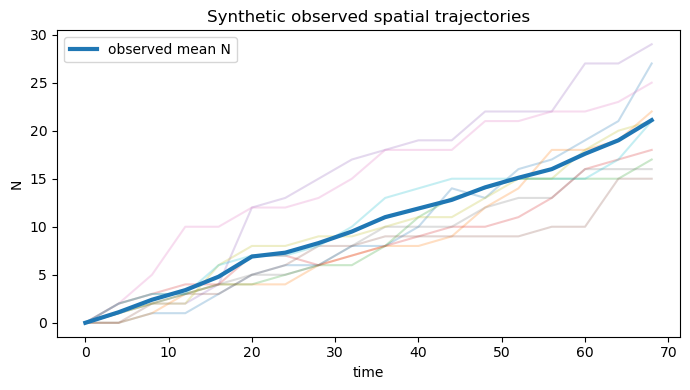

In [10]:
if OBS_MODE == "synthetic_spatial":
    print("Generating synthetic observed spatial data...")
    obs_runs = run_spatial_diagnostic_many(
        TRUE_K12_SITE,
        TRUE_K21_BASE,
        times_obs,
        n_reps=N_OBS_REPS,
        seed=OBS_SEED,
        spatial_kwargs=SPATIAL_KWARGS,
    )
else:
    raise NotImplementedError("For experimental data, load your observed trajectories into obs_runs or directly define summary_obs.")

summary_obs = summarize_runs(obs_runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY)
distance_to_obs = make_distance_function(summary_obs)

mapped_obs = report_map_from_spatial_runs(obs_runs, TRUE_K12_SITE)
print("Observed summary length:", len(summary_obs))
print("Report map of synthetic observed spatial truth:")
print(mapped_obs)

plt.figure(figsize=(7, 4))
for r in obs_runs[:min(20, len(obs_runs))]:
    plt.plot(times_obs, r["N"], alpha=0.25)
plt.plot(times_obs, mean_traj(obs_runs, "N"), linewidth=3, label="observed mean N")
plt.xlabel("time")
plt.ylabel("N")
plt.title("Synthetic observed spatial trajectories")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Population prior and SMC helper functions

In [11]:
def sample_prior_phi(rng, n):
    """Sample log population parameters phi = [log k12_ctmc, log k21_ctmc]."""
    k12 = log_uniform(rng, K12_CTMC_MIN, K12_CTMC_MAX, size=int(n))
    k21 = log_uniform(rng, K21_CTMC_MIN, K21_CTMC_MAX, size=int(n))
    return np.column_stack([np.log(k12), np.log(k21)])


def phi_to_pop(theta_phi):
    theta_phi = np.asarray(theta_phi, dtype=float)
    return float(np.exp(theta_phi[0])), float(np.exp(theta_phi[1]))


def phi_in_bounds(theta_phi):
    k12, k21 = phi_to_pop(theta_phi)
    return (K12_CTMC_MIN <= k12 <= K12_CTMC_MAX) and (K21_CTMC_MIN <= k21 <= K21_CTMC_MAX)


def log_prior_phi(theta_phi):
    """Log-uniform prior in parameter scale = uniform prior in log scale on bounds."""
    if not phi_in_bounds(theta_phi):
        return -np.inf
    return -np.log(np.log(K12_CTMC_MAX) - np.log(K12_CTMC_MIN)) - np.log(np.log(K21_CTMC_MAX) - np.log(K21_CTMC_MIN))


def weighted_cov(X, w):
    X = np.asarray(X, dtype=float)
    w = np.asarray(w, dtype=float)
    w = w / np.sum(w)
    mu = np.sum(X * w[:, None], axis=0)
    Xm = X - mu
    return (Xm.T * w) @ Xm


def mixture_logpdf_common_cov(phi, particles, weights, Sigma):
    phi = np.asarray(phi, dtype=float)
    particles = np.asarray(particles, dtype=float)
    weights = np.asarray(weights, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    d = particles.shape[1]
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        return -np.inf
    inv = np.linalg.inv(Sigma)
    diffs = particles - phi[None, :]
    quad = np.einsum("ij,jk,ik->i", diffs, inv, diffs)
    log_norm = -0.5 * (d * np.log(2 * np.pi) + logdet)
    return float(logsumexp(np.log(weights + 1e-300) + log_norm - 0.5 * quad))

## 11. Multi-level candidate evaluator

In [12]:
def evaluate_multilevel_candidate(phi, seed, eps_pop=None, eps_short=None, eps_spatial=None):
    """
    Multi-level delayed-acceptance evaluation.

    Level 0: cheap CTMC distance.
    Level 1: GP maps population params to spatial params.
    Level 2: short spatial distance, optional screen.
    Level 3: full spatial distance, final ABC distance.
    """
    phi = np.asarray(phi, dtype=float)
    if not phi_in_bounds(phi):
        return dict(status="out_of_bounds", accepted=False, phi0=phi[0], phi1=phi[1])

    k12_ctmc, k21_ctmc = phi_to_pop(phi)

    # Cheap population CTMC screen
    try:
        pop_runs = simulate_ctmc_many(
            R01_CTMC_FIXED,
            K10_CTMC_FIXED,
            k12_ctmc,
            k21_ctmc,
            times_obs,
            n_reps=N_POP_REPS,
            seed=seed,
        )
        d_pop = distance_to_obs(summarize_runs(pop_runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY))
    except Exception as e:
        return dict(status="pop_error", accepted=False, error_message=str(e), k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc)

    if eps_pop is not None and d_pop > eps_pop:
        return dict(status="pop_reject", accepted=False, k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, d_pop=d_pop)

    # GP inverse map to spatial parameters
    try:
        k12_site, k21_base = predict_spatial_from_population_gp(k12_ctmc, k21_ctmc)
    except Exception as e:
        return dict(status="gp_error", accepted=False, error_message=str(e), k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, d_pop=d_pop)

    # Optional short spatial screen
    d_short = np.nan
    if N_SPATIAL_REPS_SHORT > 0:
        try:
            short_runs = run_spatial_diagnostic_many(
                k12_site,
                k21_base,
                times_obs,
                n_reps=N_SPATIAL_REPS_SHORT,
                seed=seed + 11111,
                spatial_kwargs=SPATIAL_KWARGS,
            )
            d_short = distance_to_obs(summarize_runs(short_runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY))
        except Exception as e:
            return dict(status="short_spatial_error", accepted=False, error_message=str(e), k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, k12_site=k12_site, k21_base=k21_base, d_pop=d_pop)

        if eps_short is not None and d_short > eps_short:
            return dict(status="short_reject", accepted=False, k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, k12_site=k12_site, k21_base=k21_base, d_pop=d_pop, d_short=d_short)

    # Full spatial final check
    try:
        spatial_runs = run_spatial_diagnostic_many(
            k12_site,
            k21_base,
            times_obs,
            n_reps=N_SPATIAL_REPS_FULL,
            seed=seed + 22222,
            spatial_kwargs=SPATIAL_KWARGS,
        )
        d_spatial = distance_to_obs(summarize_runs(spatial_runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY))
        mapped = report_map_from_spatial_runs(spatial_runs, k12_site)
        map_err = map_error_to_target(mapped, k12_ctmc, k21_ctmc)
    except Exception as e:
        return dict(status="full_spatial_error", accepted=False, error_message=str(e), k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, k12_site=k12_site, k21_base=k21_base, d_pop=d_pop, d_short=d_short)

    accepted = (eps_spatial is None) or (d_spatial <= eps_spatial)
    status = "accepted" if accepted else "spatial_reject"

    row = dict(
        status=status,
        accepted=bool(accepted),
        phi0=float(phi[0]),
        phi1=float(phi[1]),
        k12_ctmc=float(k12_ctmc),
        k21_ctmc=float(k21_ctmc),
        k12_site=float(k12_site),
        k21_base=float(k21_base),
        d_pop=float(d_pop),
        d_short=float(d_short),
        d_spatial=float(d_spatial),
        map_error=float(map_err),
    )
    row.update({f"mapped_{k}": v for k, v in mapped.items()})
    return row

## 12. Pilot run: calibrate cheap and expensive tolerances

In [13]:
def calibrate_multilevel_thresholds(seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    phi_pilot = sample_prior_phi(rng, N_PILOT)
    seeds = rng.integers(1, 2**31 - 1, size=N_PILOT, dtype=np.int64)

    print("Pilot cheap CTMC screen...")
    t0 = time.perf_counter()

    def _cheap(i):
        phi = phi_pilot[i]
        k12_ctmc, k21_ctmc = phi_to_pop(phi)
        try:
            pop_runs = simulate_ctmc_many(
                R01_CTMC_FIXED, K10_CTMC_FIXED, k12_ctmc, k21_ctmc,
                times_obs, n_reps=N_POP_REPS, seed=int(seeds[i])
            )
            d_pop = distance_to_obs(summarize_runs(pop_runs, keys=SUMMARY_KEYS, use_variance=USE_VARIANCE_IN_SUMMARY))
            return dict(i=i, phi0=phi[0], phi1=phi[1], k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, d_pop=d_pop, status="ok")
        except Exception as e:
            return dict(i=i, phi0=phi[0], phi1=phi[1], k12_ctmc=k12_ctmc, k21_ctmc=k21_ctmc, d_pop=np.inf, status="error", error_message=str(e))

    cheap_rows = _parallel_map(_cheap, list(range(N_PILOT)))
    df_cheap = pd.DataFrame(cheap_rows)
    finite_pop = df_cheap[np.isfinite(df_cheap["d_pop"])]
    eps_pop = float(np.percentile(finite_pop["d_pop"], PILOT_POP_QUANTILE))
    print(f"Pilot cheap done in {format_seconds(time.perf_counter()-t0)}")
    print("eps_pop:", eps_pop)

    # Select candidates passing cheap screen, but cap expensive pilot cost.
    df_pass = df_cheap[np.isfinite(df_cheap["d_pop"]) & (df_cheap["d_pop"] <= eps_pop)].copy()
    df_pass = df_pass.sort_values("d_pop").head(PILOT_MAX_SPATIAL).copy()
    print("Pilot spatial evaluations:", len(df_pass))

    t1 = time.perf_counter()
    items = list(df_pass.to_dict("records"))

    def _spatial(row):
        phi = np.array([row["phi0"], row["phi1"]], dtype=float)
        return evaluate_multilevel_candidate(
            phi,
            seed=int(seed + 10_000 + int(row["i"]) * 100),
            eps_pop=eps_pop,
            eps_short=None,
            eps_spatial=None,
        )

    spatial_rows = _parallel_map(_spatial, items)
    df_spatial = pd.DataFrame(spatial_rows)
    finite_short = df_spatial[np.isfinite(df_spatial["d_short"])]
    finite_spatial = df_spatial[np.isfinite(df_spatial["d_spatial"])]

    if len(finite_spatial) == 0:
        raise RuntimeError("No finite spatial pilot distances. Loosen settings or debug spatial simulation.")

    eps_short = float(np.percentile(finite_short["d_short"], PILOT_SHORT_QUANTILE)) if len(finite_short) > 0 else None
    eps_spatial = float(np.percentile(finite_spatial["d_spatial"], PILOT_SPATIAL_QUANTILE))

    print(f"Pilot spatial done in {format_seconds(time.perf_counter()-t1)}")
    print("eps_short:", eps_short)
    print("eps_spatial:", eps_spatial)

    return eps_pop, eps_short, eps_spatial, df_cheap, df_spatial


eps_pop0, eps_short0, eps_spatial0, df_pilot_pop, df_pilot_spatial = calibrate_multilevel_thresholds()

print("Pilot status counts:")
print(df_pilot_spatial["status"].value_counts(dropna=False))

Pilot cheap CTMC screen...
Pilot cheap done in 0.8s
eps_pop: 0.34655767543764426
Pilot spatial evaluations: 40
Pilot spatial done in 8.0s
eps_short: 0.7371259418592608
eps_spatial: 0.42275748138681585
Pilot status counts:
status
accepted      29
pop_reject    11
Name: count, dtype: int64


## 13. Run multi-level SMC-ABC

In [14]:
@dataclass
class MultiLevelSMCResult:
    particles_phi: np.ndarray
    weights: np.ndarray
    rows: pd.DataFrame
    eps_pop_history: list
    eps_short_history: list
    eps_spatial_history: list


def run_multilevel_smc_abc(
    P=P_PARTICLES,
    G=G_GENERATIONS,
    eps_pop_init=eps_pop0,
    eps_short_init=eps_short0,
    eps_spatial_init=eps_spatial0,
    seed=RANDOM_SEED + 999,
):
    rng = np.random.default_rng(seed)
    all_rows = []

    particles = None
    weights = None
    dists = None

    eps_pop = float(eps_pop_init)
    eps_short = None if eps_short_init is None else float(eps_short_init)
    eps_spatial = float(eps_spatial_init)

    eps_pop_hist = [eps_pop]
    eps_short_hist = [eps_short]
    eps_spatial_hist = [eps_spatial]

    for g in range(int(G)):
        gen = g + 1
        print("=" * 80)
        print(f"Generation {gen}/{G}")
        print(f"eps_pop={eps_pop:.5g}, eps_short={eps_short}, eps_spatial={eps_spatial:.5g}")
        t_gen = time.perf_counter()

        if g == 0:
            Sigma = None
        else:
            C = weighted_cov(particles, weights)
            Sigma = COV_SCALE * C + 1e-8 * np.eye(2)

        new_particles = []
        new_rows = []
        new_logw = []
        proposals_seen = 0
        batch_id = 0

        while len(new_particles) < int(P):
            if proposals_seen >= MAX_PROPOSALS_PER_GENERATION:
                raise RuntimeError(
                    f"Generation {gen} stopped after {proposals_seen} proposals with "
                    f"{len(new_particles)}/{P} accepted. Loosen tolerances or increase max proposals."
                )

            batch_size = max(int(P), int(BATCH_FACTOR) * int(P))
            batch_id += 1

            if g == 0:
                props = sample_prior_phi(rng, batch_size)
            else:
                anc = rng.choice(int(P), size=batch_size, p=weights)
                props = particles[anc] + rng.multivariate_normal(mean=np.zeros(2), cov=Sigma, size=batch_size)

            seeds = rng.integers(1, 2**31 - 1, size=batch_size, dtype=np.int64)

            def _work(j):
                row = evaluate_multilevel_candidate(
                    props[j],
                    seed=int(seeds[j]),
                    eps_pop=eps_pop,
                    eps_short=eps_short,
                    eps_spatial=eps_spatial,
                )
                row["generation"] = gen
                row["batch_id"] = batch_id
                row["proposal_index_in_batch"] = int(j)
                return row

            rows = _parallel_map(_work, list(range(batch_size)))
            proposals_seen += batch_size
            all_rows.extend(rows)

            accepted_rows = [r for r in rows if r.get("accepted", False)]
            print(
                f"batch {batch_id}: accepted this batch {len(accepted_rows)}, "
                f"total accepted {len(new_particles) + len(accepted_rows)}/{P}, "
                f"proposals seen {proposals_seen}"
            )

            for r in accepted_rows:
                phi = np.array([r["phi0"], r["phi1"]], dtype=float)

                if g == 0:
                    logw = 0.0
                else:
                    lp = log_prior_phi(phi)
                    lq = mixture_logpdf_common_cov(phi, particles, weights, Sigma)
                    logw = lp - lq

                new_particles.append(phi)
                new_rows.append(r)
                new_logw.append(logw)

                if len(new_particles) >= int(P):
                    break

        particles = np.asarray(new_particles[:int(P)], dtype=float)
        df_new = pd.DataFrame(new_rows[:int(P)])
        dists = df_new["d_spatial"].to_numpy(dtype=float)

        if g == 0:
            weights = np.ones(int(P), dtype=float) / float(P)
        else:
            logw = np.asarray(new_logw[:int(P)], dtype=float)
            logw -= logsumexp(logw)
            weights = np.exp(logw)

        # Decrease only spatial tolerance. Keep cheap screen loose to avoid false negatives.
        eps_spatial = min(float(eps_spatial), float(np.percentile(dists, EPS_SPATIAL_UPDATE_QUANTILE)))
        eps_spatial_hist.append(eps_spatial)
        eps_pop_hist.append(eps_pop)
        eps_short_hist.append(eps_short)

        print(f"Generation {gen} finished in {format_seconds(time.perf_counter()-t_gen)}")
        print("accepted d_spatial min/median/max:", np.min(dists), np.median(dists), np.max(dists))

    df_all = pd.DataFrame(all_rows)
    return MultiLevelSMCResult(
        particles_phi=particles,
        weights=weights,
        rows=df_all,
        eps_pop_history=eps_pop_hist,
        eps_short_history=eps_short_hist,
        eps_spatial_history=eps_spatial_hist,
    )


res_ml = run_multilevel_smc_abc()

print("Finished multi-level SMC-ABC.")
print("eps_spatial_history:", res_ml.eps_spatial_history)

Generation 1/3
eps_pop=0.34656, eps_short=0.7371259418592608, eps_spatial=0.42276
batch 1: accepted this batch 37, total accepted 37/30, proposals seen 120
Generation 1 finished in 13.1s
accepted d_spatial min/median/max: 0.21467336642516338 0.3418481372009049 0.41513518770588315
Generation 2/3
eps_pop=0.34656, eps_short=0.7371259418592608, eps_spatial=0.34185
batch 1: accepted this batch 10, total accepted 10/30, proposals seen 120
batch 2: accepted this batch 14, total accepted 24/30, proposals seen 240
batch 3: accepted this batch 10, total accepted 34/30, proposals seen 360
Generation 2 finished in 24.8s
accepted d_spatial min/median/max: 0.19440564053745654 0.28793919972453297 0.3407365680275336
Generation 3/3
eps_pop=0.34656, eps_short=0.7371259418592608, eps_spatial=0.28794
batch 1: accepted this batch 5, total accepted 5/30, proposals seen 120
batch 2: accepted this batch 5, total accepted 10/30, proposals seen 240
batch 3: accepted this batch 8, total accepted 18/30, proposals

## 14. Save results

In [15]:
out_dir = Path("multistage_abc_outputs")
out_dir.mkdir(exist_ok=True)

rows_csv = out_dir / "multistage_abc_all_proposals.csv"
particles_csv = out_dir / "multistage_abc_final_particles.csv"

res_ml.rows.to_csv(rows_csv, index=False)

final_df = pd.DataFrame({
    "k12_ctmc": np.exp(res_ml.particles_phi[:, 0]),
    "k21_ctmc": np.exp(res_ml.particles_phi[:, 1]),
    "weight": res_ml.weights,
})
final_df.to_csv(particles_csv, index=False)

print("Saved:")
print(rows_csv.resolve())
print(particles_csv.resolve())

Saved:
C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\multistage_abc_outputs\multistage_abc_all_proposals.csv
C:\Users\Khang\Desktop\abchandbook\prc-recruitment-bayesian-analysis\python_version\multistage_abc_outputs\multistage_abc_final_particles.csv


## 15. Diagnostics and posterior plots

All proposal status counts:
status
out_of_bounds     582
spatial_reject    244
short_reject      144
pop_reject        129
accepted          101
Name: count, dtype: int64

Status by generation:
status      accepted  out_of_bounds  pop_reject  short_reject  spatial_reject
generation                                                                   
1                 37              0          32            27              24
2                 34            206          36            31              53
3                 30            376          61            86             167


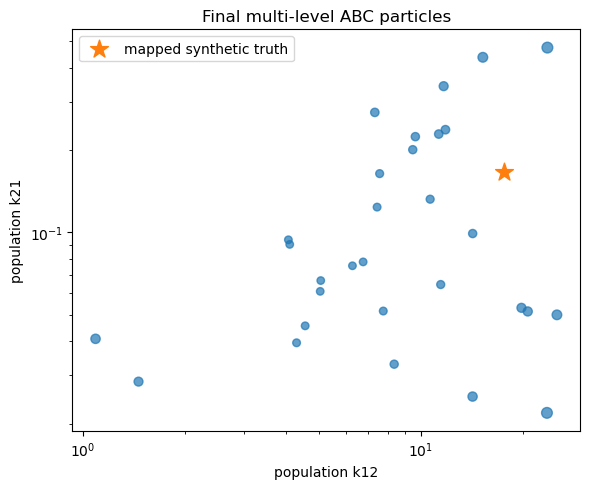

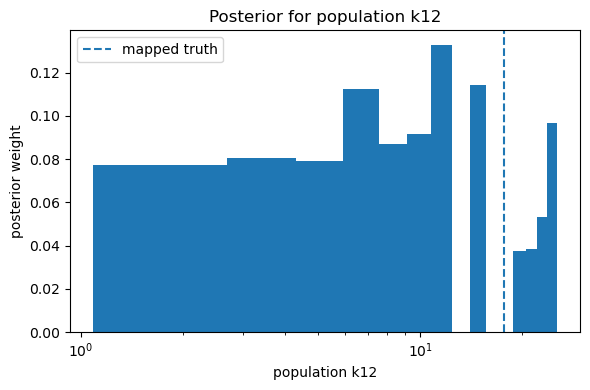

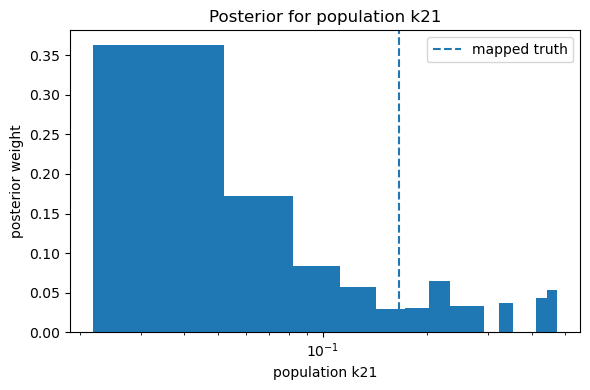

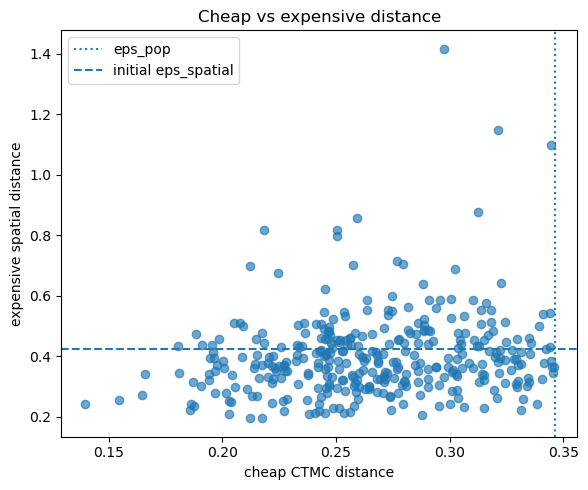

Final posterior weighted means:
k12_ctmc mean: 11.548150213094887
k21_ctmc mean: 0.13944249133216996
Final posterior weighted medians are not printed; use weighted quantiles if needed.


In [16]:
df_rows = res_ml.rows.copy()
print("All proposal status counts:")
print(df_rows["status"].value_counts(dropna=False))

# Pass rates by generation
print("\nStatus by generation:")
print(pd.crosstab(df_rows["generation"], df_rows["status"]))

# Posterior particles
k12_post = np.exp(res_ml.particles_phi[:, 0])
k21_post = np.exp(res_ml.particles_phi[:, 1])
w = res_ml.weights

# If synthetic obs was used, mark the effective mapped CTMC pair from the spatial truth.
true_k12_eff = mapped_obs.get("k12_hat_capped", np.nan)
true_k21_eff = mapped_obs.get("k21_hat_actual", np.nan)

plt.figure(figsize=(6, 5))
plt.scatter(k12_post, k21_post, s=60 * (w / np.max(w)), alpha=0.7)
if np.isfinite(true_k12_eff) and np.isfinite(true_k21_eff):
    plt.scatter([true_k12_eff], [true_k21_eff], marker="*", s=180, label="mapped synthetic truth")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("population k12")
plt.ylabel("population k21")
plt.title("Final multi-level ABC particles")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(k12_post, bins=15, weights=w)
if np.isfinite(true_k12_eff):
    plt.axvline(true_k12_eff, linestyle="--", label="mapped truth")
plt.xscale("log")
plt.xlabel("population k12")
plt.ylabel("posterior weight")
plt.title("Posterior for population k12")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(k21_post, bins=15, weights=w)
if np.isfinite(true_k21_eff):
    plt.axvline(true_k21_eff, linestyle="--", label="mapped truth")
plt.xscale("log")
plt.xlabel("population k21")
plt.ylabel("posterior weight")
plt.title("Posterior for population k21")
plt.legend()
plt.tight_layout()
plt.show()

# Cheap-vs-expensive distance diagnostic
finite_full = df_rows[np.isfinite(df_rows.get("d_spatial", np.nan)) & np.isfinite(df_rows.get("d_pop", np.nan))]
if len(finite_full) > 0:
    plt.figure(figsize=(6, 5))
    plt.scatter(finite_full["d_pop"], finite_full["d_spatial"], alpha=0.65)
    plt.axvline(eps_pop0, linestyle=":", label="eps_pop")
    plt.axhline(eps_spatial0, linestyle="--", label="initial eps_spatial")
    plt.xlabel("cheap CTMC distance")
    plt.ylabel("expensive spatial distance")
    plt.title("Cheap vs expensive distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("Final posterior weighted means:")
print("k12_ctmc mean:", float(np.sum(w * k12_post)))
print("k21_ctmc mean:", float(np.sum(w * k21_post)))
print("Final posterior weighted medians are not printed; use weighted quantiles if needed.")

## 16. Optional: inspect accepted spatial parameters predicted by GP

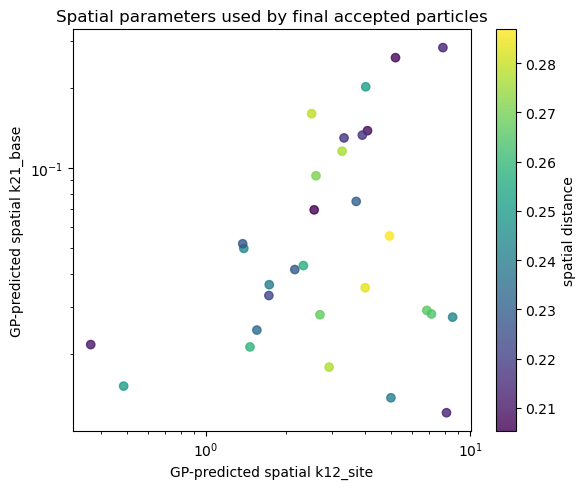

,k12_ctmc,k21_ctmc,k12_site,k21_base,d_pop,d_short,d_spatial,map_error,mapped_k12_hat_capped,mapped_k21_hat_actual
511,5.056131,0.066618,1.733287,0.036321,0.300027,0.618433,0.239864,0.073270,4.952249,0.062097
530,14.238807,0.098945,4.942934,0.055376,0.319656,0.547555,0.286875,0.081710,14.828802,0.092171
539,11.826418,0.237028,4.082181,0.137833,0.202738,0.645043,0.208302,0.075058,11.792967,0.219900
560,11.451784,0.064429,4.001620,0.035374,0.300861,0.621399,0.283421,0.063069,11.004455,0.061355
572,7.553457,0.163813,2.604880,0.093286,0.164663,0.550149,0.270685,0.069346,7.724816,0.153410
640,8.339478,0.032968,2.920779,0.017795,0.196703,0.716891,0.277079,0.049488,8.762337,0.032916
660,10.656627,0.132089,3.699254,0.074702,0.306316,0.544421,0.230249,0.068210,11.097763,0.125041
678,19.854839,0.052961,6.846574,0.029065,0.243403,0.635498,0.265543,0.080128,20.539722,0.049253
690,6.274840,0.075446,2.165789,0.041415,0.248497,0.597759,0.228043,0.051122,6.497367,0.072677
717,1.460103,0.028468,0.487152,0.015094,0.226641,0.671961,0.250787,0.082135,1.419699,0.026353


In [17]:
accepted_df = df_rows[df_rows["accepted"].astype(bool)].copy()
if len(accepted_df) > 0:
    last_gen = accepted_df["generation"].max()
    last_acc = accepted_df[accepted_df["generation"] == last_gen].copy()

    plt.figure(figsize=(6, 5))
    plt.scatter(last_acc["k12_site"], last_acc["k21_base"], c=last_acc["d_spatial"], alpha=0.8)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("GP-predicted spatial k12_site")
    plt.ylabel("GP-predicted spatial k21_base")
    plt.title("Spatial parameters used by final accepted particles")
    plt.colorbar(label="spatial distance")
    plt.tight_layout()
    plt.show()

    display(last_acc[[
        "k12_ctmc", "k21_ctmc", "k12_site", "k21_base",
        "d_pop", "d_short", "d_spatial", "map_error",
        "mapped_k12_hat_capped", "mapped_k21_hat_actual",
    ]].head(20))